In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import OLSInfluence

**1. Non-linearity of the Data**

In [59]:
df = pd.read_csv("Auto.csv")

# Remover valores inválidos en horsepower
df = df[df['horsepower'] != '?']
df['horsepower'] = df['horsepower'].astype(float)

# Variables
y = df['mpg']
hp = df['horsepower']

In [60]:
# Modelo lineal
X1 = sm.add_constant(hp)
model1 = sm.OLS(y, X1).fit()

fitted1 = model1.predict(X1)
resid1 = y - fitted1

In [61]:
# Crear columna hp²
df['hp2'] = df['horsepower'] ** 2

# Modelo cuadrático
X2 = sm.add_constant(df[['horsepower', 'hp2']])
model2 = sm.OLS(y, X2).fit()

fitted2 = model2.predict(X2)     # <--- AQUÍ DEFINE fitted2
resid2 = y - fitted2

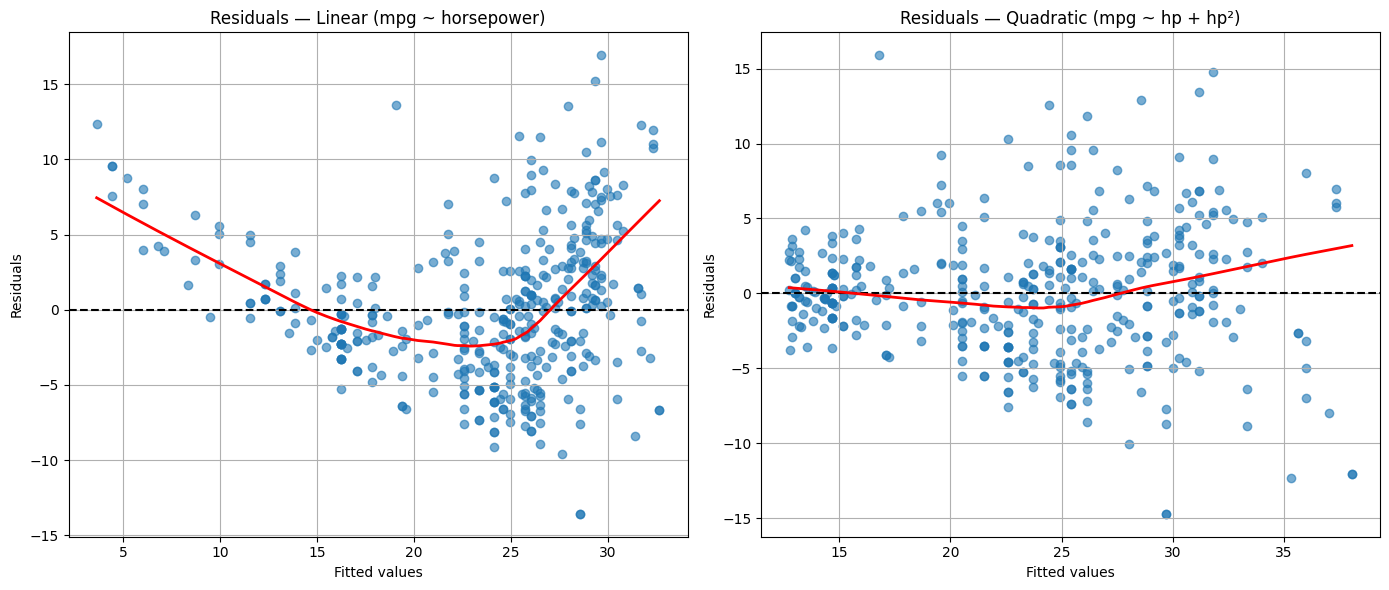

In [62]:
#GRÁFICA
plt.figure(figsize=(14,6))

#Left plot: LINEAR
plt.subplot(1,2,1)
plt.scatter(fitted1, resid1, alpha=0.6)
plt.axhline(0, color='black', linestyle='--')

# LOWESS para ver tendencia
smooth1 = lowess(resid1, fitted1)
plt.plot(smooth1[:,0], smooth1[:,1], color='red', linewidth=2)

plt.title("Residuals — Linear (mpg ~ horsepower)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(True)


#Right plot: QUADRATIC
plt.subplot(1,2,2)
plt.scatter(fitted2, resid2, alpha=0.6)
plt.axhline(0, color='black', linestyle='--')

#LOWESS
smooth2 = lowess(resid2, fitted2)
plt.plot(smooth2[:,0], smooth2[:,1], color='red', linewidth=2)

plt.title("Residuals — Quadratic (mpg ~ hp + hp²)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(True)

plt.tight_layout()
plt.show()

**2. Correlation of Error Terms**

In [67]:
#Ajustar modelo mpg ~ hp
X = sm.add_constant(hp)
model = sm.OLS(y, X).fit()
fitted = model.predict(X)
resid = y - fitted

# rho = 0  → residuales originales
resid_rho0 = resid

# rho = 0.5 → suavizado leve (lo correlaciona moderadamente)
resid_rho5 = pd.Series(resid).rolling(window=3, center=True, min_periods=1).mean().values

# rho = 0.9 → suavizado fuerte (alta correlación)
resid_rho9 = pd.Series(resid).rolling(window=10, center=True, min_periods=1).mean().values

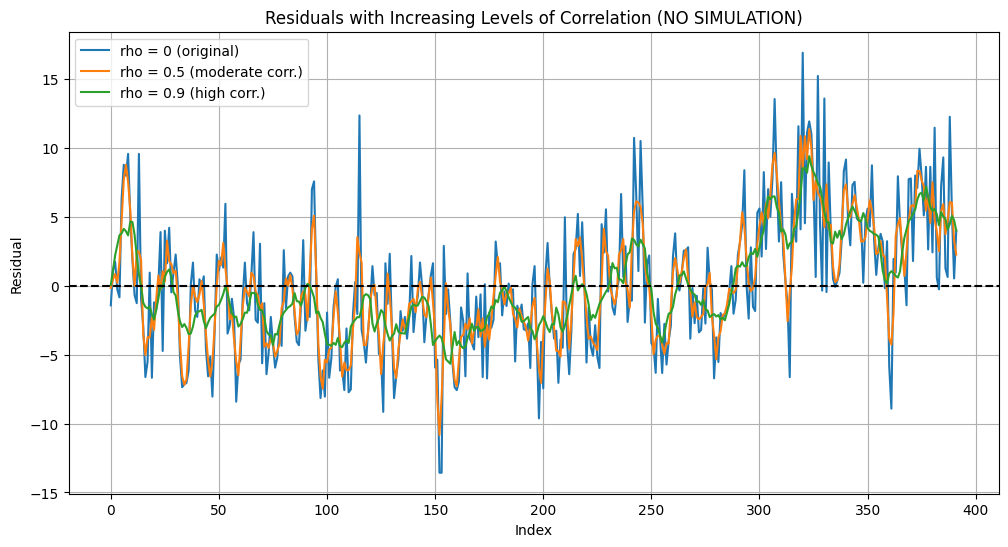

In [68]:
#GRÁFICA
plt.figure(figsize=(12,6))

plt.plot(resid_rho0, label="rho = 0 (original)")
plt.plot(resid_rho5, label="rho = 0.5 (moderate corr.)")
plt.plot(resid_rho9, label="rho = 0.9 (high corr.)")

plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("Residuals with Increasing Levels of Correlation (NO SIMULATION)")
plt.grid(True)
plt.legend()
plt.show()

**3. Non-constant Variance of Error Terms**

In [70]:
#Modelo 1: mpg ~ horsepower
X1 = sm.add_constant(hp)
model1 = sm.OLS(y, X1).fit()
fitted1 = model1.predict(X1)
resid1 = y - fitted1


#Modelo 2: mpg ~ log(horsepower)
log_hp = np.log(hp)
X2 = sm.add_constant(log_hp)
model2 = sm.OLS(y, X2).fit()
fitted2 = model2.predict(X2)
resid2 = y - fitted2


#Función para bandas azules de cuantiles

def quantile_band(residuals, fitted, q):
    df_tmp = pd.DataFrame({"fit": fitted, "resid": residuals})
    df_tmp = df_tmp.sort_values("fit")
    window = 20   # suaviza los cuantiles
    q_list = []

    for i in range(len(df_tmp)):
        lo = max(0, i - window)
        hi = min(len(df_tmp), i + window)
        q_list.append(np.percentile(df_tmp["resid"].iloc[lo:hi], q))

    smooth_q = lowess(q_list, df_tmp["fit"], frac=0.3)
    return smooth_q

upper1 = quantile_band(resid1, fitted1, 95)
lower1 = quantile_band(resid1, fitted1, 5)

upper2 = quantile_band(resid2, fitted2, 95)
lower2 = quantile_band(resid2, fitted2, 5)

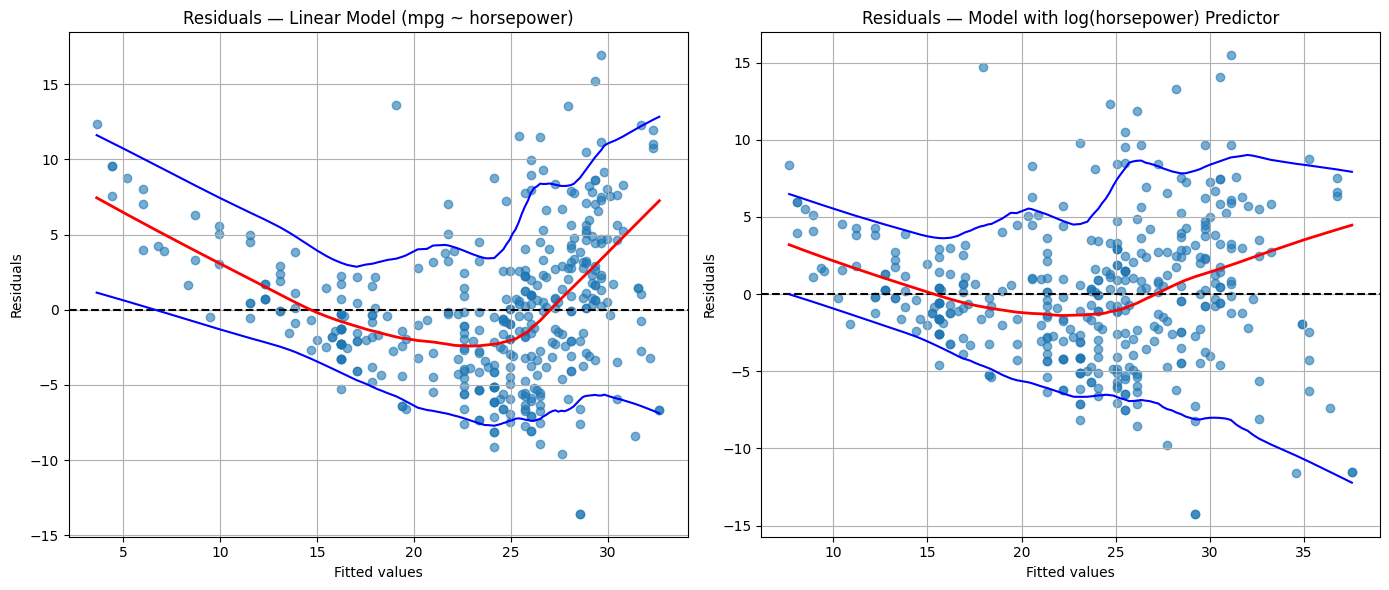

In [71]:
#GRÁFICA
plt.figure(figsize=(14,6))

#LEFT
plt.subplot(1,2,1)
plt.scatter(fitted1, resid1, alpha=0.6)
plt.axhline(0, color="black", linestyle="--")

# LOWESS
smooth1 = lowess(resid1, fitted1)
plt.plot(smooth1[:,0], smooth1[:,1], color="red", linewidth=2)

# Líneas azul claro (cuantiles)
plt.plot(upper1[:,0], upper1[:,1], color="blue")
plt.plot(lower1[:,0], lower1[:,1], color="blue")

plt.title("Residuals — Linear Model (mpg ~ horsepower)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(True)

#RIGHT
plt.subplot(1,2,2)
plt.scatter(fitted2, resid2, alpha=0.6)
plt.axhline(0, color="black", linestyle="--")

# LOWESS
smooth2 = lowess(resid2, fitted2)
plt.plot(smooth2[:,0], smooth2[:,1], color="red", linewidth=2)

# Cuantiles
plt.plot(upper2[:,0], upper2[:,1], color="blue")
plt.plot(lower2[:,0], lower2[:,1], color="blue")

plt.title("Residuals — Model with log(horsepower) Predictor")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(True)

plt.tight_layout()
plt.show()

**4. Outliers**

In [83]:
#Modelo completo mpg ~ hp
X_hp = sm.add_constant(hp)
model_full = sm.OLS(mpg, X_hp).fit()

# Studentized residuals
influence = OLSInfluence(model_full)
stud_resid = influence.resid_studentized_external

# Outlier (el valor más extremo)
outlier_idx = np.argmax(np.abs(stud_resid))
print("Índice del outlier:", outlier_idx)
print("Studentized residual:", stud_resid[outlier_idx])


#Modelo sin el outlier
df_no = df.drop(df.index[outlier_idx])
mpg_no = df_no["mpg"].values
hp_no = df_no["horsepower"].values

X_hp_no = sm.add_constant(hp_no)
model_no = sm.OLS(mpg_no, X_hp_no).fit()


hp_line = np.linspace(hp.min(), hp.max(), 300)
X_line = sm.add_constant(hp_line)
y_full_line = model_full.predict(X_line)
y_no_line = model_no.predict(X_line)


#RESIDUALS (para plot del centro)

fitted_full = model_full.predict(X_hp)
resid_full = mpg - fitted_full

Índice del outlier: 320
Studentized residual: 3.508708808796348


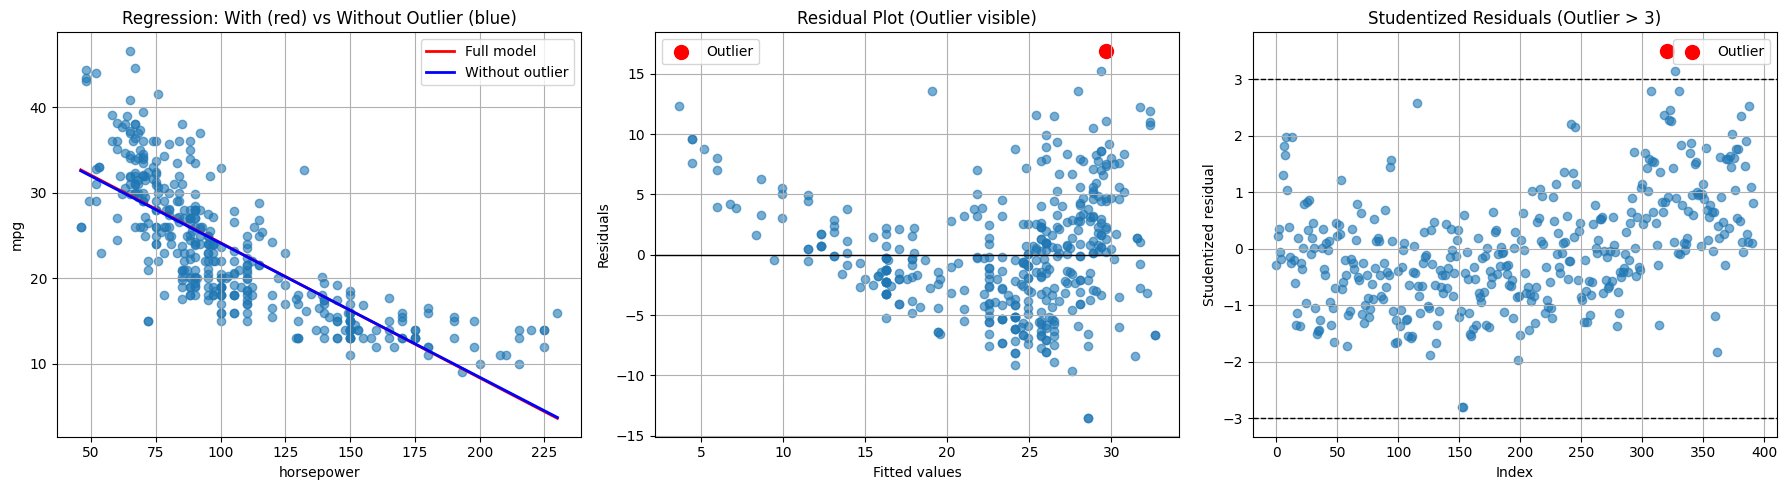

In [84]:
plt.figure(figsize=(18,5))

#LEFT: Regression lines
plt.subplot(1,3,1)
plt.scatter(hp, mpg, alpha=0.6)

plt.plot(hp_line, y_full_line, color="red", linewidth=2, label="Full model")
plt.plot(hp_line, y_no_line, color="blue", linewidth=2, label="Without outlier")

plt.title("Regression: With (red) vs Without Outlier (blue)")
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.legend()
plt.grid(True)

#CENTER: Residual plot
plt.subplot(1,3,2)
plt.scatter(fitted_full, resid_full, alpha=0.6)
plt.axhline(0, color='black', linewidth=1)

# Outlier pintado en rojo EXACTO como tu gráfica
plt.scatter(fitted_full[outlier_idx], resid_full[outlier_idx],
            color="red", s=100, label="Outlier")

plt.title("Residual Plot (Outlier visible)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(True)
plt.legend()


#RIGHT: Studentized residuals
plt.subplot(1,3,3)
plt.scatter(range(len(stud_resid)), stud_resid, alpha=0.6)

# Líneas horizontales
plt.axhline(3, color="black", linestyle="--", linewidth=1)
plt.axhline(-3, color="black", linestyle="--", linewidth=1)

# Outlier en rojo
plt.scatter(outlier_idx, stud_resid[outlier_idx],
            color="red", s=100, label="Outlier")

plt.title("Studentized Residuals (Outlier > 3)")
plt.xlabel("Index")
plt.ylabel("Studentized residual")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**5. High Leverage Points**

In [90]:
#Modelo: mpg ~ hp
X = sm.add_constant(hp)
model_full = sm.OLS(y, X).fit()

influence = OLSInfluence(model_full)
leverages = influence.hat_matrix_diag
stud_resid = influence.resid_studentized_external
resid = model_full.resid

#Elegir punto de ALTA leverage
high_lev_idx = np.argmax(leverages)

print("High leverage index:", high_lev_idx)
print("Leverage value:", leverages[high_lev_idx])
print("Studentized residual:", stud_resid[high_lev_idx])


#Modelo
df_no = df.drop(df.index[high_lev_idx])
hp_no = df_no["horsepower"].values
mpg_no = df_no["mpg"].values

X_no = sm.add_constant(hp_no)
model_no = sm.OLS(mpg_no, X_no).fit()


#Líneas de regresión
hp_line = np.linspace(hp.min(), hp.max(), 300)

X_line = sm.add_constant(hp_line)
y_full_line = model_full.predict(X_line)
y_no_line = model_no.predict(X_line)

High leverage index: 115
Leverage value: 0.029753001790921437
Studentized residual: 2.57803340708155


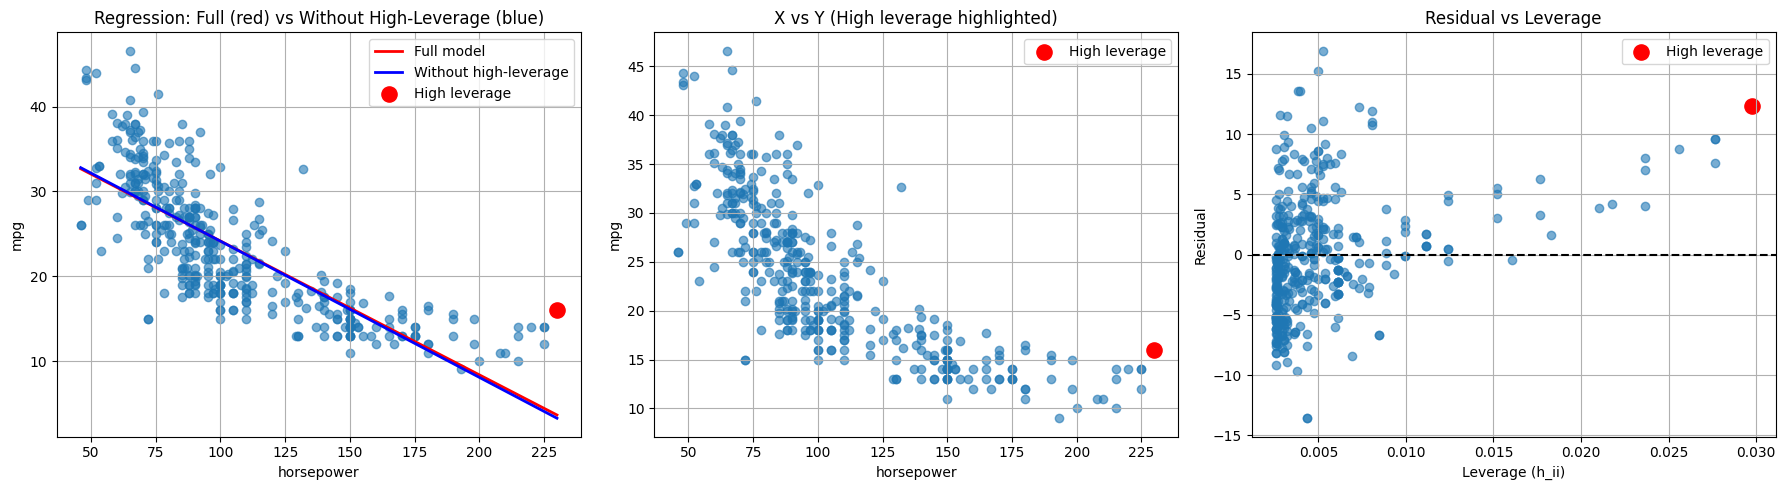

In [91]:
#GRÁFICAS
plt.figure(figsize=(18,5))


#LEFT: Regression lines
plt.subplot(1,3,1)

plt.scatter(hp, mpg, alpha=0.6)

plt.plot(hp_line, y_full_line, color="red", linewidth=2, label="Full model")
plt.plot(hp_line, y_no_line, color="blue", linewidth=2, label="Without high-leverage")

plt.scatter(hp[high_lev_idx], mpg[high_lev_idx],
            color="red", s=120, label="High leverage")

plt.title("Regression: Full (red) vs Without High-Leverage (blue)")
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.legend()
plt.grid(True)

#CENTER: High leverage in X–Y space
plt.subplot(1,3,2)

plt.scatter(hp, mpg, alpha=0.6)
plt.scatter(hp[high_lev_idx], mpg[high_lev_idx],
            color="red", s=120, label="High leverage")

plt.title("X vs Y (High leverage highlighted)")
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.legend()
plt.grid(True)

#RIGHT: leverage vs residual
plt.subplot(1,3,3)

plt.scatter(leverages, resid, alpha=0.6)
plt.scatter(leverages[high_lev_idx], resid[high_lev_idx],
            color="red", s=120, label="High leverage")

plt.axhline(0, color="black", linestyle="--")

plt.title("Residual vs Leverage")
plt.xlabel("Leverage (h_ii)")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**6. Collinearity**

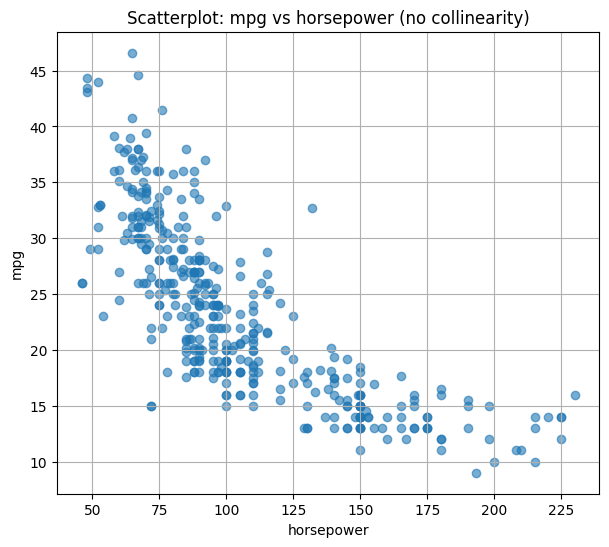

In [101]:
#GRÁFICA
plt.figure(figsize=(7,6))

plt.scatter(hp, y, alpha=0.6)

plt.title("Scatterplot: mpg vs horsepower (no collinearity)")
plt.xlabel("horsepower")
plt.ylabel("mpg")
plt.grid(True)

plt.show()